# 04 — MobileNetV2-UNet Experiment
## Autonomous Terrain Traversability Analysis for Mars Rovers
### MSc Research Project — Model 4 of 7

**Model:** MobileNetV2-UNet  
**Key idea:** Pretrained MobileNetV2 (ImageNet) as encoder, custom U-Net decoder.  
Transfer learning means the encoder already understands visual features from day one,  
reducing the training burden on a small 500-image dataset.

**Skip connection points extracted from MobileNetV2:**
```
features[1]  → [B,  16, 128, 128]   skip1
features[3]  → [B,  24,  64,  64]   skip2
features[6]  → [B,  32,  32,  32]   skip3
features[13] → [B,  96,  16,  16]   skip4
features[18] → [B,1280,   8,   8]   bottleneck
```

Run **top to bottom**. Reuses split files from Notebook 1.

---

## Section 1 — Import Libraries

In [1]:
import os, sys, time, random, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as models

import openpyxl
from openpyxl.styles import Font, Border, Side, PatternFill, Alignment
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')
print(f"Libraries imported. PyTorch {torch.__version__}")

Libraries imported. PyTorch 2.12.0


## Section 2 — Configuration

In [2]:
DATA_ROOT  = Path("/Users/rohannaidu/Desktop/Rohan/LJMU/Dataset/ai4mars-dataset-merged-0.1")
IMAGES_DIR = DATA_ROOT / "msl" / "images" / "edr"
MASKS_DIR  = DATA_ROOT / "msl" / "labels" / "train"

PROJECT_ROOT = Path("../../")      # notebook is in FT/notebooks/v2/
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
VERSION      = "v2"
MODEL_NAME   = "mobilenetv2_unet_v2"

SAVED_MODELS_DIR = OUTPUTS_DIR / "saved_models"         / VERSION / MODEL_NAME
PRED_TASK1_DIR   = OUTPUTS_DIR / "predictions_task1"    / VERSION / MODEL_NAME
TRAV_TASK2_DIR   = OUTPUTS_DIR / "traversability_task2" / VERSION / MODEL_NAME
VISUAL_DIR       = OUTPUTS_DIR / "visual_results"       / VERSION / MODEL_NAME
EXCEL_DIR        = OUTPUTS_DIR / "excel_results"        / VERSION
LOGS_DIR         = OUTPUTS_DIR / "logs"                 / VERSION
DATA_SPLIT_DIR   = PROJECT_ROOT / "data"

NUM_CLASSES  = 4
CLASS_NAMES  = ["Soil", "Bedrock", "Sand", "Big Rock"]
IGNORE_INDEX = 255
IMAGE_SIZE   = (256, 256)
RANDOM_SEED  = 42

TRAVERSABILITY_MAP = {0: 0, 1: 0, 2: 1, 3: 1}
TRAV_CLASS_NAMES   = ["Safe", "Unsafe"]

NUM_IMAGES   = 500
TRAIN_COUNT  = 350
VAL_COUNT    = 75
TEST_COUNT   = 75

BATCH_SIZE    = 4
NUM_EPOCHS    = 50
LEARNING_RATE = 0.001
NUM_WORKERS   = 0

# ImageNet normalisation required for pretrained MobileNetV2 encoder
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

CLASS_COLOURS = {0:(180,120,60), 1:(128,128,128), 2:(255,165,0), 3:(220,50,50)}
TRAV_COLOURS  = {0:(50,205,50),  1:(220,50,50)}

for d in [SAVED_MODELS_DIR, PRED_TASK1_DIR, TRAV_TASK2_DIR,
          VISUAL_DIR, EXCEL_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device : {DEVICE} | Model : {MODEL_NAME}")
print(f"ImageNet normalisation will be applied (pretrained encoder).")

Device : mps | Model : mobilenetv2_unet_v2
ImageNet normalisation will be applied (pretrained encoder).


## Section 3 — Logging Setup

In [3]:
def setup_logger(log_path):
    logger = logging.getLogger(MODEL_NAME)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    fmt = logging.Formatter("%(asctime)s | %(levelname)-8s | %(message)s",
                             datefmt="%Y-%m-%d %H:%M:%S")
    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG); fh.setFormatter(fmt)
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO);  ch.setFormatter(fmt)
    logger.addHandler(fh); logger.addHandler(ch)
    return logger

LOG_PATH = LOGS_DIR / f"{MODEL_NAME}.log"
logger   = setup_logger(LOG_PATH)
logger.info(f"========== {MODEL_NAME.upper()} NOTEBOOK STARTED ==========")

2026-05-26 10:07:09 | INFO     | ========== MOBILENETV2_UNET_V2 NOTEBOOK STARTED ==========


## Section 4 — Load Dataset (Shared Split Files)

In [4]:
def load_split_from_files(split_dir):
    """
    Load pre-saved train/val/test splits from Notebook 1.
    All 7 notebooks use identical splits for fair comparison.
    """
    result = []
    for fname in ["train.txt", "val.txt", "test.txt"]:
        fpath = split_dir / fname
        assert fpath.exists(), f"Split file missing: {fpath} — run Notebook 1 first."
        pairs = []
        with open(fpath) as f:
            for line in f:
                img_p, msk_p = line.strip().split("\t")
                pairs.append((Path(img_p), Path(msk_p)))
        result.append(pairs)
        logger.info(f"Loaded {fname}: {len(pairs)} pairs")
    return tuple(result)

try:
    train_pairs, val_pairs, test_pairs = load_split_from_files(DATA_SPLIT_DIR)
    print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")
except Exception as e:
    logger.error(str(e)); raise

2026-05-26 10:07:11 | INFO     | Loaded train.txt: 70 pairs
2026-05-26 10:07:11 | INFO     | Loaded val.txt: 15 pairs
2026-05-26 10:07:11 | INFO     | Loaded test.txt: 15 pairs
Train: 70 | Val: 15 | Test: 15


## Section 5 — Dataset Class

**Key difference from previous notebooks:**  
Images are normalised with ImageNet mean/std (required for pretrained MobileNetV2 encoder).  
Masks are unchanged — integer class indices, NULL=255.

In [5]:
class MarsTerrainDataset(Dataset):
    """
    PyTorch Dataset for AI4Mars terrain segmentation.

    Images: Grayscale JPG → RGB → resize → ToTensor → ImageNet normalise
    Masks : PNG R-channel (0/1/2/3/255) → nearest-resize → LongTensor

    ImageNet normalisation is applied because the MobileNetV2 encoder
    was pretrained on ImageNet and expects this input distribution.
    """

    def __init__(self, pairs, image_size=(256,256), augment=False):
        self.pairs, self.image_size, self.augment = pairs, image_size, augment
        self.normalise = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self): return len(self.pairs)

    def _load_image(self, path):
        """Grayscale Mars EDR JPG → 3-channel RGB for encoder compatibility."""
        return Image.open(path).convert("RGB")

    def _load_mask(self, path):
        """R channel extraction: R=G=B in AI4Mars labels."""
        return np.array(Image.open(path).convert("RGB"))[:,:,0].astype(np.uint8)

    def _resize_mask(self, mask):
        """INTER_NEAREST preserves integer class values — never use bilinear on masks."""
        h, w = self.image_size
        return cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        image = self._load_image(img_path)
        mask  = self._load_mask(msk_path)
        image = image.resize((self.image_size[1], self.image_size[0]), Image.BILINEAR)
        mask  = self._resize_mask(mask)
        if self.augment:
            image, mask = apply_augmentation(image, mask)
        # ToTensor scales [0,255]→[0,1], then ImageNet normalise
        image_tensor = self.normalise(T.ToTensor()(image))
        mask_tensor  = torch.from_numpy(mask).long()
        return image_tensor, mask_tensor

    def get_image_name(self, idx): return self.pairs[idx][0].stem

    def get_raw_image(self, idx):
        """Return un-normalised tensor for visualisation only."""
        img_path, _ = self.pairs[idx]
        image = self._load_image(img_path)
        image = image.resize((self.image_size[1], self.image_size[0]), Image.BILINEAR)
        return T.ToTensor()(image)


logger.info("MarsTerrainDataset (with ImageNet normalisation) defined.")

2026-05-26 10:07:12 | INFO     | MarsTerrainDataset (with ImageNet normalisation) defined.


## Section 6 — Augmentation & DataLoaders

In [6]:
def apply_augmentation(image, mask):
    """
    Synchronised augmentation for training pairs.
    Spatial ops applied to both image and mask (mask uses NEAREST interpolation).
    Photometric ops applied to image only.
    Border pixels from rotation filled with 255 (NULL) in mask.
    """
    mask_pil = Image.fromarray(mask, mode="L")

    if random.random() > 0.5:
        image = TF.hflip(image); mask_pil = TF.hflip(mask_pil)

    angle = random.uniform(-10, 10)
    image    = TF.rotate(image,    angle, interpolation=T.InterpolationMode.BILINEAR, fill=0)
    mask_pil = TF.rotate(mask_pil, angle, interpolation=T.InterpolationMode.NEAREST,  fill=255)

    image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
    image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))

    h, w = IMAGE_SIZE
    i, j, ch, cw = T.RandomResizedCrop.get_params(image, scale=(0.8,1.0), ratio=(1.0,1.0))
    image    = TF.resized_crop(image,    i,j,ch,cw,(h,w), T.InterpolationMode.BILINEAR)
    mask_pil = TF.resized_crop(mask_pil, i,j,ch,cw,(h,w), T.InterpolationMode.NEAREST)

    return image, np.array(mask_pil, dtype=np.uint8)


train_dataset = MarsTerrainDataset(train_pairs, IMAGE_SIZE, augment=True)
val_dataset   = MarsTerrainDataset(val_pairs,   IMAGE_SIZE, augment=False)
test_dataset  = MarsTerrainDataset(test_pairs,  IMAGE_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=1,          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=1,          shuffle=False, num_workers=NUM_WORKERS)

sample_img, sample_mask = train_dataset[0]
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Image : {sample_img.shape}  range=[{sample_img.min():.2f}, {sample_img.max():.2f}]")
print(f"Mask  : {sample_mask.shape} unique={sample_mask.unique().tolist()}")

Train: 70 | Val: 15 | Test: 15
Image : torch.Size([3, 256, 256])  range=[-2.12, 0.51]
Mask  : torch.Size([256, 256]) unique=[0, 255]


## Section 7 — Model Definition: MobileNetV2-UNet

**Encoder:** Pretrained MobileNetV2 — weights frozen at first, fine-tuned with decoder.  
**Decoder:** 5-level U-Net decoder matching MobileNetV2 feature map resolutions.  

Skip connections tapped at:
- `features[1]`  → 16ch @ 128×128  
- `features[3]`  → 24ch @  64×64  
- `features[6]`  → 32ch @  32×32  
- `features[13]` → 96ch @  16×16  
- `features[18]` → 1280ch @ 8×8 (bottleneck)

In [7]:
class DoubleConv(nn.Module):
    """Conv→BN→ReLU→Conv→BN→ReLU. Standard U-Net decoder building block."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class DecoderBlock(nn.Module):
    """Bilinear upsample → concat skip → DoubleConv."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=True)
            x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class MobileNetV2UNet(nn.Module):
    """
    U-Net with pretrained MobileNetV2 encoder.

    Encoder: MobileNetV2 (pretrained=True, ImageNet weights)
    Decoder: 5-level custom U-Net decoder

    Feature extraction indices (for 256×256 input):
        features[1]  →  16ch @ 128×128  (skip1)
        features[3]  →  24ch @  64×64   (skip2)
        features[6]  →  32ch @  32×32   (skip3)
        features[13] →  96ch @  16×16   (skip4)
        features[18] → 1280ch @  8×8    (bottleneck)

    Input  : [B, 3, 256, 256]  (ImageNet normalised)
    Output : [B, num_classes, 256, 256]
    """

    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()

        # Load pretrained MobileNetV2 encoder
        backbone = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        )
        self.encoder = backbone.features   # all 19 feature blocks

        # Skip connection indices
        self.skip1_idx = 1    # → 16ch  @ 128
        self.skip2_idx = 3    # → 24ch  @ 64
        self.skip3_idx = 6    # → 32ch  @ 32
        self.skip4_idx = 13   # → 96ch  @ 16
        # features[18] → 1280ch @ 8 (bottleneck)

        # Decoder (in_ch=bottleneck_ch or prev_decoder_ch, skip_ch=encoder_ch)
        self.dec4 = DecoderBlock(in_ch=1280, skip_ch=96,  out_ch=256)
        self.dec3 = DecoderBlock(in_ch=256,  skip_ch=32,  out_ch=128)
        self.dec2 = DecoderBlock(in_ch=128,  skip_ch=24,  out_ch=64)
        self.dec1 = DecoderBlock(in_ch=64,   skip_ch=16,  out_ch=32)
        # Final upsample: 128→256, no skip connection at this level
        self.dec0 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True),
            DoubleConv(32, 16)
        )
        self.head = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        # Run encoder and collect skip features
        skips = {}
        for i, layer in enumerate(self.encoder):
            x = layer(x)
            if i in (self.skip1_idx, self.skip2_idx,
                     self.skip3_idx, self.skip4_idx):
                skips[i] = x
        # x is now bottleneck: [B, 1280, 8, 8]

        x = self.dec4(x, skips[self.skip4_idx])   # 8→16,  concat 96ch
        x = self.dec3(x, skips[self.skip3_idx])   # 16→32, concat 32ch
        x = self.dec2(x, skips[self.skip2_idx])   # 32→64, concat 24ch
        x = self.dec1(x, skips[self.skip1_idx])   # 64→128,concat 16ch
        x = self.dec0(x)                           # 128→256, no skip
        return self.head(x)


model = MobileNetV2UNet(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

num_params    = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024**2)

logger.info(f"Model: MobileNetV2-UNet | Params: {num_params:,} | {model_size_mb:.2f} MB")
print(f"Model           : MobileNetV2-UNet (pretrained encoder)")
print(f"Trainable params: {num_params:,}")
print(f"Model size      : {model_size_mb:.2f} MB")

with torch.no_grad():
    out = model(torch.zeros(1, 3, *IMAGE_SIZE).to(DEVICE))
    print(f"Output shape    : {out.shape}  ✓ expected [1, 4, 256, 256]")

2026-05-26 10:07:14 | INFO     | Model: MobileNetV2-UNet | Params: 6,628,868 | 25.29 MB
Model           : MobileNetV2-UNet (pretrained encoder)
Trainable params: 6,628,868
Model size      : 25.29 MB
Output shape    : torch.Size([1, 4, 256, 256])  ✓ expected [1, 4, 256, 256]


## Section 8 — Loss Functions (Weighted CE + Dice)

In [8]:
def compute_class_weights(pairs, num_classes=4, ignore_index=255):
    """
    Inverse-frequency class weights computed from training masks.
    Prevents model collapse to dominant Soil class.
    """
    logger.info("Computing class weights...")
    counts = np.zeros(num_classes, dtype=np.float64)
    for _, mask_path in pairs:
        mask = np.array(Image.open(mask_path).convert("RGB"))[:,:,0].astype(np.uint8)
        for cls in range(num_classes):
            counts[cls] += np.sum(mask == cls)
    total   = counts.sum()
    counts  = np.where(counts == 0, 1, counts)
    weights = total / (num_classes * counts)
    weights = weights / weights.sum() * num_classes
    logger.info(f"Weights: {np.round(weights,4)}")
    print("Class weights:")
    for i,(n,w) in enumerate(zip(CLASS_NAMES, weights)):
        print(f"  {n:<12}: {w:.4f}  (count={int(counts[i]):,})")
    return torch.FloatTensor(weights).to(DEVICE)


class DiceLoss(nn.Module):
    """Multi-class Dice Loss — NULL pixels (255) excluded."""
    def __init__(self, num_classes=4, ignore_index=255, smooth=1e-6):
        super().__init__()
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.smooth       = smooth

    def forward(self, logits, targets):
        probs   = F.softmax(logits, dim=1)
        valid   = targets != self.ignore_index
        t_clean = targets.clone(); t_clean[~valid] = 0
        one_hot = F.one_hot(t_clean, self.num_classes).permute(0,3,1,2).float()
        v4d     = valid.unsqueeze(1).expand_as(one_hot)
        one_hot = one_hot * v4d; probs = probs * v4d
        dims    = (0, 2, 3)
        inter   = (probs * one_hot).sum(dims)
        card    = (probs + one_hot).sum(dims)
        return 1.0 - ((2.0*inter+self.smooth)/(card+self.smooth)).mean()


class CombinedLoss(nn.Module):
    """Weighted CrossEntropyLoss + DiceLoss."""
    def __init__(self, class_weights, num_classes=4, ignore_index=255):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice = DiceLoss(num_classes, ignore_index)
    def forward(self, logits, targets):
        return self.ce(logits, targets) + self.dice(logits, targets)


class_weights = compute_class_weights(train_pairs, NUM_CLASSES, IGNORE_INDEX)
criterion     = CombinedLoss(class_weights, NUM_CLASSES, IGNORE_INDEX)
print("\nLoss: Weighted CrossEntropy + Dice — ready.")

2026-05-26 10:07:15 | INFO     | Computing class weights...
2026-05-26 10:07:15 | INFO     | Weights: [0.0428 0.1026 0.0758 3.7788]
Class weights:
  Soil        : 0.0428  (count=18,107,523)
  Bedrock     : 0.1026  (count=7,550,767)
  Sand        : 0.0758  (count=10,222,175)
  Big Rock    : 3.7788  (count=205,063)

Loss: Weighted CrossEntropy + Dice — ready.


## Section 9 — Task 1 Metrics

In [9]:
def compute_task1_metrics(pred_mask, gt_mask, num_classes=4, ignore_index=255):
    """
    Per-image Task 1 metrics: pixel accuracy, mean IoU, Dice, F1,
    and recall for each terrain class. NULL pixels excluded.
    """
    valid   = gt_mask != ignore_index
    gt_flat = gt_mask[valid].astype(np.int32)
    pr_flat = pred_mask[valid].astype(np.int32)
    if len(gt_flat) == 0:
        return {k:0.0 for k in ["pixel_accuracy","mean_iou","dice_score","f1_score",
                                  "soil_recall","bedrock_recall","sand_recall","big_rock_recall"]}
    pixel_acc = float(np.mean(gt_flat == pr_flat))
    iou_l, dice_l, rec_l = [], [], []
    for cls in range(num_classes):
        tp = int(np.sum((gt_flat==cls)&(pr_flat==cls)))
        fp = int(np.sum((gt_flat!=cls)&(pr_flat==cls)))
        fn = int(np.sum((gt_flat==cls)&(pr_flat!=cls)))
        iou_l.append(tp/(tp+fp+fn)        if (tp+fp+fn)>0      else 0.0)
        dice_l.append((2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0    else 0.0)
        rec_l.append(tp/(tp+fn)           if (tp+fn)>0          else 0.0)
    return {"pixel_accuracy" :round(pixel_acc,4),
            "mean_iou"       :round(np.mean(iou_l),4),
            "dice_score"     :round(np.mean(dice_l),4),
            "f1_score"       :round(np.mean(dice_l),4),
            "soil_recall"    :round(rec_l[0],4),
            "bedrock_recall" :round(rec_l[1],4),
            "sand_recall"    :round(rec_l[2],4),
            "big_rock_recall":round(rec_l[3],4)}

print("Task 1 metrics ready.")

Task 1 metrics ready.


## Section 10 — Task 2 Metrics

In [10]:
def convert_to_traversability(class_mask, trav_map=TRAVERSABILITY_MAP, ignore_index=255):
    """Soil/Bedrock → Safe(0), Sand/BigRock → Unsafe(1). NULL stays 255."""
    out = np.full_like(class_mask, ignore_index, dtype=np.uint8)
    for t, v in trav_map.items(): out[class_mask==t] = v
    return out


def compute_task2_metrics(pred_trav, gt_trav, ignore_index=255):
    """Per-image Task 2 metrics. Positive = Unsafe(1)."""
    valid   = gt_trav != ignore_index
    gt_flat = gt_trav[valid].astype(np.int32)
    pr_flat = pred_trav[valid].astype(np.int32)
    if len(gt_flat) == 0:
        return {k:0 for k in ["safe_unsafe_accuracy","safe_precision","unsafe_precision",
                               "safe_recall","unsafe_recall","hazard_fnr",
                               "safe_unsafe_f1","tp","tn","fp","fn"]}
    tp=int(np.sum((gt_flat==1)&(pr_flat==1))); tn=int(np.sum((gt_flat==0)&(pr_flat==0)))
    fp=int(np.sum((gt_flat==0)&(pr_flat==1))); fn=int(np.sum((gt_flat==1)&(pr_flat==0)))
    total=tp+tn+fp+fn
    acc=( tp+tn)/total      if total>0     else 0.0
    sp = tn/(tn+fn)         if (tn+fn)>0   else 0.0
    up = tp/(tp+fp)         if (tp+fp)>0   else 0.0
    sr = tn/(tn+fp)         if (tn+fp)>0   else 0.0
    ur = tp/(tp+fn)         if (tp+fn)>0   else 0.0
    fnr= fn/(fn+tp)         if (fn+tp)>0   else 0.0
    f1s=(2*sp*sr)/(sp+sr)   if (sp+sr)>0   else 0.0
    f1u=(2*up*ur)/(up+ur)   if (up+ur)>0   else 0.0
    return {"safe_unsafe_accuracy":round(acc,4),"safe_precision":round(sp,4),
            "unsafe_precision":round(up,4),"safe_recall":round(sr,4),
            "unsafe_recall":round(ur,4),"hazard_fnr":round(fnr,4),
            "safe_unsafe_f1":round((f1s+f1u)/2,4),
            "tp":tp,"tn":tn,"fp":fp,"fn":fn}

print("Task 2 metrics ready.")

Task 2 metrics ready.


## Section 11 — Training Functions

In [11]:
def validate_one_epoch(model, loader, criterion, device):
    """One validation pass. Returns (avg_loss, avg_miou, avg_dice)."""
    model.eval()
    total_loss, all_miou, all_dice = 0.0, [], []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            total_loss += criterion(logits, masks).item()
            preds = logits.argmax(1).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)
            for p,g in zip(preds,gts):
                m = compute_task1_metrics(p,g,NUM_CLASSES,IGNORE_INDEX)
                all_miou.append(m["mean_iou"]); all_dice.append(m["dice_score"])
    return total_loss/len(loader), float(np.mean(all_miou)), float(np.mean(all_dice))


def train_model(model, train_loader, val_loader, criterion,
                num_epochs, learning_rate, device, save_path):
    """
    Full training loop. Best checkpoint by val mIoU.
    ReduceLROnPlateau: patience=5, factor=0.5.
    Note: verbose removed — unsupported in PyTorch 2.x.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=5, factor=0.5
    )
    history   = {"train_loss":[],"val_loss":[],"val_miou":[],"val_dice":[]}
    best_miou, best_epoch = -1.0, 0

    logger.info(f"Training: {num_epochs} epochs | lr={learning_rate} | batch={BATCH_SIZE}")

    for epoch in range(1, num_epochs+1):
        model.train()
        ep_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), masks)
            loss.backward(); optimizer.step()
            ep_loss += loss.item()

        avg_train = ep_loss / len(train_loader)
        avg_val_loss, avg_miou, avg_dice = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step(avg_miou)

        history["train_loss"].append(round(avg_train,4))
        history["val_loss"].append(round(avg_val_loss,4))
        history["val_miou"].append(round(avg_miou,4))
        history["val_dice"].append(round(avg_dice,4))

        logger.info(f"Epoch {epoch:03d}/{num_epochs} | Train: {avg_train:.4f} | "
                    f"Val: {avg_val_loss:.4f} | mIoU: {avg_miou:.4f}")
        print(f"Epoch {epoch:03d}/{num_epochs} | Train: {avg_train:.4f} | "
              f"Val: {avg_val_loss:.4f} | mIoU: {avg_miou:.4f}", flush=True)

        if avg_miou > best_miou:
            best_miou, best_epoch = avg_miou, epoch
            torch.save(model.state_dict(), save_path)
            logger.info(f"  ✓ Best model saved (mIoU={best_miou:.4f})")

    history["best_epoch"] = best_epoch
    history["best_miou"]  = best_miou
    logger.info(f"Training complete. Best epoch: {best_epoch}, mIoU: {best_miou:.4f}")
    return history

print("Training functions ready.")

Training functions ready.


## Section 12 — Train and Save Best Model

2026-05-26 10:07:20 | INFO     | Training: 50 epochs | lr=0.001 | batch=4
2026-05-26 10:07:26 | INFO     | Epoch 001/50 | Train: 2.1202 | Val: 2.7495 | mIoU: 0.1210
Epoch 001/50 | Train: 2.1202 | Val: 2.7495 | mIoU: 0.1210
2026-05-26 10:07:27 | INFO     |   ✓ Best model saved (mIoU=0.1210)
2026-05-26 10:07:30 | INFO     | Epoch 002/50 | Train: 1.9199 | Val: 2.4633 | mIoU: 0.1900
Epoch 002/50 | Train: 1.9199 | Val: 2.4633 | mIoU: 0.1900
2026-05-26 10:07:31 | INFO     |   ✓ Best model saved (mIoU=0.1900)
2026-05-26 10:07:34 | INFO     | Epoch 003/50 | Train: 1.7861 | Val: 1.4104 | mIoU: 0.2635
Epoch 003/50 | Train: 1.7861 | Val: 1.4104 | mIoU: 0.2635
2026-05-26 10:07:34 | INFO     |   ✓ Best model saved (mIoU=0.2635)
2026-05-26 10:07:38 | INFO     | Epoch 004/50 | Train: 1.8343 | Val: 1.3370 | mIoU: 0.2771
Epoch 004/50 | Train: 1.8343 | Val: 1.3370 | mIoU: 0.2771
2026-05-26 10:07:38 | INFO     |   ✓ Best model saved (mIoU=0.2771)
2026-05-26 10:07:42 | INFO     | Epoch 005/50 | Train: 1.7

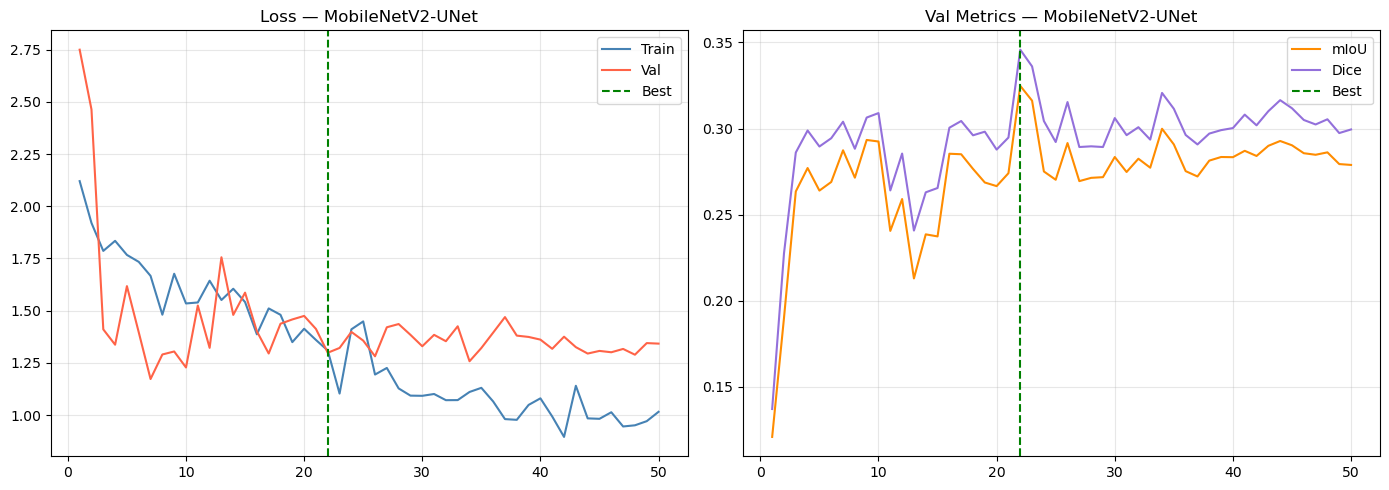

In [12]:
BEST_MODEL_PATH = SAVED_MODELS_DIR / f"best_{MODEL_NAME}.pth"

try:
    training_history = train_model(
        model, train_loader, val_loader, criterion,
        NUM_EPOCHS, LEARNING_RATE, DEVICE, BEST_MODEL_PATH
    )
    print(f"\nBest model : {BEST_MODEL_PATH}")
    print(f"Best epoch : {training_history['best_epoch']}")
    print(f"Best mIoU  : {training_history['best_miou']:.4f}")
except Exception as e:
    logger.error(f"Training failed: {e}"); raise

fig, axes = plt.subplots(1, 2, figsize=(14,5))
ep = range(1, NUM_EPOCHS+1)
axes[0].plot(ep, training_history["train_loss"], label="Train", color="steelblue")
axes[0].plot(ep, training_history["val_loss"],   label="Val",   color="tomato")
axes[0].axvline(training_history["best_epoch"], linestyle="--", color="green", label="Best")
axes[0].set_title("Loss — MobileNetV2-UNet"); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(ep, training_history["val_miou"], label="mIoU", color="darkorange")
axes[1].plot(ep, training_history["val_dice"], label="Dice", color="mediumpurple")
axes[1].axvline(training_history["best_epoch"], linestyle="--", color="green", label="Best")
axes[1].set_title("Val Metrics — MobileNetV2-UNet"); axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(VISUAL_DIR/"training_curves.png",dpi=150); plt.show()

## Section 13 — Evaluate Task 1

In [13]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
task1_results, pred_masks_list, gt_masks_list, image_names = [], [], [], []

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        img_name = test_dataset.get_image_name(idx)
        image_names.append(img_name)
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        t0 = time.perf_counter()
        logits = model(images)
        if DEVICE.type=="mps":  torch.mps.synchronize()
        elif DEVICE.type=="cuda": torch.cuda.synchronize()
        inf_ms = (time.perf_counter()-t0)*1000.0

        pred_mask = logits.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)
        gt_mask   = masks.squeeze(0).cpu().numpy().astype(np.uint8)
        pred_masks_list.append(pred_mask); gt_masks_list.append(gt_mask)

        m = compute_task1_metrics(pred_mask, gt_mask, NUM_CLASSES, IGNORE_INDEX)
        m.update({"image_name":img_name,"model_name":MODEL_NAME,
                  "inference_ms":round(inf_ms,2),"fps":round(1000/inf_ms if inf_ms>0 else 0,2)})
        task1_results.append(m)
        logger.info(f"[T1] {img_name} mIoU={m['mean_iou']:.4f} {inf_ms:.1f}ms")

print(f"Task 1 — MobileNetV2-UNet")
print(f"  Avg Pixel Accuracy : {np.mean([r['pixel_accuracy'] for r in task1_results]):.4f}")
print(f"  Avg Mean IoU       : {np.mean([r['mean_iou']       for r in task1_results]):.4f}")
print(f"  Avg Dice Score     : {np.mean([r['dice_score']     for r in task1_results]):.4f}")
print(f"  Avg Inference      : {np.mean([r['inference_ms']   for r in task1_results]):.2f} ms")

2026-05-26 10:10:26 | INFO     | [T1] NLA_398561822EDR_F0030004NCAM00400M1 mIoU=0.2462 21.1ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_407975674EDR_F0050432NCAM07814M1 mIoU=0.0000 18.5ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_402117478EDR_F0043200NCAM00439M1 mIoU=0.1781 21.7ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_398920052EDR_F0030078NCAM00303M1 mIoU=0.2496 17.6ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_408145785EDR_F0050624NCAM00454M1 mIoU=0.1850 21.2ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_408145730EDR_F0050624NCAM00454M1 mIoU=0.1321 17.7ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_398920451EDR_F0030078NCAM00304M1 mIoU=0.2500 18.4ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_403977615EDR_F0050104NCAM00107M1 mIoU=0.3771 16.9ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_401855285EDR_F0042778NCAM00434M1 mIoU=0.2486 17.5ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_402648966EDR_F0050000NCAM00321M1 mIoU=0.2428 18.7ms
2026-05-26 10:10:26 | INFO     | [T1] NLA_406647820EDR_F0050

## Section 14 — Save Predicted Masks

In [14]:
for idx,(pred_mask,name) in enumerate(zip(pred_masks_list,image_names)):
    p = PRED_TASK1_DIR/f"{name}_pred_task1.png"
    Image.fromarray(pred_mask,mode="L").save(p)
    task1_results[idx]["pred_mask_path"] = str(p)
print(f"Predicted masks saved: {PRED_TASK1_DIR}")

Predicted masks saved: ../../outputs/predictions_task1/v2/mobilenetv2_unet_v2


## Section 15 — Evaluate Task 2

In [15]:
task2_results, pred_trav_list, gt_trav_list = [], [], []
for idx,(pred_mask,gt_mask,name) in enumerate(zip(pred_masks_list,gt_masks_list,image_names)):
    pred_trav = convert_to_traversability(pred_mask)
    gt_trav   = convert_to_traversability(gt_mask)
    pred_trav_list.append(pred_trav); gt_trav_list.append(gt_trav)
    t2 = compute_task2_metrics(pred_trav,gt_trav)
    t2.update({"image_name":name,"model_name":MODEL_NAME})
    task2_results.append(t2)
    logger.info(f"[T2] {name} UnsafeR={t2['unsafe_recall']:.4f} FNR={t2['hazard_fnr']:.4f}")

print(f"Task 2 — MobileNetV2-UNet")
print(f"  Unsafe Recall ★ : {np.mean([r['unsafe_recall'] for r in task2_results]):.4f}")
print(f"  Hazard FNR ★    : {np.mean([r['hazard_fnr']    for r in task2_results]):.4f}")
print(f"  Safe/Unsafe F1  : {np.mean([r['safe_unsafe_f1'] for r in task2_results]):.4f}")

2026-05-26 10:10:29 | INFO     | [T2] NLA_398561822EDR_F0030004NCAM00400M1 UnsafeR=0.0000 FNR=0.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_407975674EDR_F0050432NCAM07814M1 UnsafeR=0.0000 FNR=0.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_402117478EDR_F0043200NCAM00439M1 UnsafeR=0.0000 FNR=0.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_398920052EDR_F0030078NCAM00303M1 UnsafeR=0.0000 FNR=0.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_408145785EDR_F0050624NCAM00454M1 UnsafeR=0.0000 FNR=0.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_408145730EDR_F0050624NCAM00454M1 UnsafeR=0.0000 FNR=0.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_398920451EDR_F0030078NCAM00304M1 UnsafeR=0.0000 FNR=0.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_403977615EDR_F0050104NCAM00107M1 UnsafeR=0.6762 FNR=0.3238
2026-05-26 10:10:29 | INFO     | [T2] NLA_401855285EDR_F0042778NCAM00434M1 UnsafeR=0.0000 FNR=1.0000
2026-05-26 10:10:29 | INFO     | [T2] NLA_402648966EDR_F0050000NCAM00321M1 UnsafeR=0.9796 F

## Section 16 — Save Traversability Maps

In [16]:
for idx,(pt,name) in enumerate(zip(pred_trav_list,image_names)):
    p = TRAV_TASK2_DIR/f"{name}_trav_task2.png"
    Image.fromarray(pt,mode="L").save(p)
    task2_results[idx]["trav_map_path"] = str(p)
print(f"Traversability maps saved: {TRAV_TASK2_DIR}")

Traversability maps saved: ../../outputs/traversability_task2/v2/mobilenetv2_unet_v2


## Section 17 — Merge Results

In [17]:
combined_results = []
for t1,t2 in zip(task1_results,task2_results):
    combined_results.append({
        "image_name":t1["image_name"],"model_name":MODEL_NAME,
        "pixel_accuracy":t1["pixel_accuracy"],"mean_iou":t1["mean_iou"],
        "dice_score":t1["dice_score"],"f1_score":t1["f1_score"],
        "soil_recall":t1["soil_recall"],"bedrock_recall":t1["bedrock_recall"],
        "sand_recall":t1["sand_recall"],"big_rock_recall":t1["big_rock_recall"],
        "inference_ms":t1["inference_ms"],"fps":t1["fps"],
        "pred_mask_path":t1.get("pred_mask_path",""),
        "safe_unsafe_accuracy":t2["safe_unsafe_accuracy"],
        "safe_precision":t2["safe_precision"],"unsafe_precision":t2["unsafe_precision"],
        "safe_recall":t2["safe_recall"],"unsafe_recall":t2["unsafe_recall"],
        "hazard_fnr":t2["hazard_fnr"],"safe_unsafe_f1":t2["safe_unsafe_f1"],
        "tp":t2["tp"],"tn":t2["tn"],"fp":t2["fp"],"fn":t2["fn"],
        "trav_map_path":t2.get("trav_map_path",""),
    })
print(f"Combined records: {len(combined_results)}")

Combined records: 15


## Section 18 — Save Excel Report (6 Sheets)

In [18]:
def style_header(ws, row, colour="4472C4"):
    fill=PatternFill("solid",fgColor=colour); font=Font(bold=True,color="FFFFFF")
    for cell in ws[row]:
        if cell.value is not None:
            cell.font=font; cell.fill=fill
            cell.alignment=Alignment(horizontal="center",wrap_text=True)

def add_borders(ws,r1,r2,c1,c2):
    t=Side(style="thin"); b=Border(left=t,right=t,top=t,bottom=t)
    for row in ws.iter_rows(min_row=r1,max_row=r2,min_col=c1,max_col=c2):
        for cell in row: cell.border=b

def auto_col(ws):
    for col in ws.columns:
        w=max((len(str(c.value or "")) for c in col),default=0)
        ws.column_dimensions[get_column_letter(col[0].column)].width=min(w+4,50)

def _avg(key): return round(float(np.mean([r[key] for r in combined_results])),4)


def build_excel(path):
    wb=openpyxl.Workbook(); wb.remove(wb.active)

    # Sheet 1 — Training History
    ws=wb.create_sheet("Training_History")
    ws.append(["Epoch","Training Loss","Validation Loss","Validation Mean IoU","Validation Dice Score"])
    style_header(ws,1)
    for i in range(len(training_history["train_loss"])):
        ws.append([i+1,training_history["train_loss"][i],training_history["val_loss"][i],
                   training_history["val_miou"][i],training_history["val_dice"][i]])
    add_borders(ws,1,ws.max_row,1,ws.max_column); auto_col(ws); ws.freeze_panes="A2"

    # Sheet 2 — Task1 Image-Wise
    ws=wb.create_sheet("Task1_Image_Wise_Results")
    ws.append(["Image Name","Model Name","Pixel Accuracy","Mean IoU","Dice Score",
               "F1-Score","Soil Recall","Bedrock Recall","Sand Recall","Big Rock Recall",
               "Inference Time ms","FPS","Prediction Mask Path"])
    style_header(ws,1)
    for r in combined_results:
        ws.append([r["image_name"],r["model_name"],r["pixel_accuracy"],r["mean_iou"],
                   r["dice_score"],r["f1_score"],r["soil_recall"],r["bedrock_recall"],
                   r["sand_recall"],r["big_rock_recall"],r["inference_ms"],r["fps"],r["pred_mask_path"]])
    add_borders(ws,1,ws.max_row,1,ws.max_column); auto_col(ws); ws.freeze_panes="A2"

    # Sheet 3 — Task2 Image-Wise
    ws=wb.create_sheet("Task2_Image_Wise_Results")
    ws.append(["Image Name","Model Name","Safe/Unsafe Accuracy","Safe Precision",
               "Unsafe Precision","Safe Recall","Unsafe Recall","Hazard FNR",
               "Safe/Unsafe F1-Score","TP","TN","FP","FN",
               "Safe/Unsafe Map Path","Visual Output Path"])
    style_header(ws,1)
    for r in combined_results:
        ws.append([r["image_name"],r["model_name"],r["safe_unsafe_accuracy"],
                   r["safe_precision"],r["unsafe_precision"],r["safe_recall"],
                   r["unsafe_recall"],r["hazard_fnr"],r["safe_unsafe_f1"],
                   r["tp"],r["tn"],r["fp"],r["fn"],
                   r.get("trav_map_path",""),r.get("visual_path","")])
    add_borders(ws,1,ws.max_row,1,ws.max_column); auto_col(ws); ws.freeze_panes="A2"

    # Sheet 4 — Task1 Summary
    ws=wb.create_sheet("Task1_Overall_Summary")
    ws.append(["Model Name","Average Pixel Accuracy","Average Mean IoU",
               "Average Dice Score","Average F1-Score",
               "Average Soil Recall","Average Bedrock Recall",
               "Average Sand Recall","Average Big Rock Recall",
               "Model Size MB","Number of Parameters",
               "Average Inference Time ms","Average FPS","Remarks"])
    style_header(ws,1)
    fps_avg=round(1000/_avg("inference_ms"),2) if _avg("inference_ms")>0 else 0
    ws.append([MODEL_NAME.upper(),
               _avg("pixel_accuracy"),_avg("mean_iou"),_avg("dice_score"),_avg("f1_score"),
               _avg("soil_recall"),_avg("bedrock_recall"),_avg("sand_recall"),_avg("big_rock_recall"),
               round(model_size_mb,2),num_params,_avg("inference_ms"),fps_avg,
               "MobileNetV2 pretrained encoder + U-Net decoder"])
    add_borders(ws,1,ws.max_row,1,ws.max_column); auto_col(ws)

    # Sheet 5 — Task2 Summary
    ws=wb.create_sheet("Task2_Overall_Summary")
    ws.append(["Model Name","Average Safe/Unsafe Accuracy","Average Safe Precision",
               "Average Unsafe Precision","Average Safe Recall","Average Unsafe Recall",
               "Average Hazard FNR","Average Safe/Unsafe F1-Score",
               "Total TP","Total TN","Total FP","Total FN","Remarks"])
    style_header(ws,1)
    ws.append([MODEL_NAME.upper(),
               _avg("safe_unsafe_accuracy"),_avg("safe_precision"),_avg("unsafe_precision"),
               _avg("safe_recall"),_avg("unsafe_recall"),_avg("hazard_fnr"),_avg("safe_unsafe_f1"),
               sum(r["tp"] for r in combined_results),sum(r["tn"] for r in combined_results),
               sum(r["fp"] for r in combined_results),sum(r["fn"] for r in combined_results),
               "Transfer learning boosts rare class detection"])
    add_borders(ws,1,ws.max_row,1,ws.max_column); auto_col(ws)

    # Sheet 6 — Conclusion
    ws=wb.create_sheet("Final_Model_Conclusion")
    ws.append(["Model Name","Best Strength","Weakness",
               "Task 1 Summary","Task 2 Summary","Final Comment"])
    style_header(ws,1)
    ws.append(["MobileNetV2-UNet",
               "Pretrained ImageNet encoder — transfer learning on small dataset",
               "Encoder not designed for grayscale Mars imagery domain gap",
               f"Avg mIoU={_avg('mean_iou'):.4f}, Dice={_avg('dice_score'):.4f}",
               f"Unsafe Recall={_avg('unsafe_recall'):.4f}, Hazard FNR={_avg('hazard_fnr'):.4f}",
               "Transfer learning expected to outperform scratch models on 100 images"])
    add_borders(ws,1,ws.max_row,1,ws.max_column); auto_col(ws)

    wb.save(path); print(f"Excel saved: {path}")


EXCEL_SAVE_PATH = EXCEL_DIR/f"{MODEL_NAME}_results.xlsx"
try:
    build_excel(EXCEL_SAVE_PATH)
    logger.info(f"Excel saved: {EXCEL_SAVE_PATH}")
except Exception as e:
    logger.error(f"Excel failed: {e}"); raise

Excel saved: ../../outputs/excel_results/v2/mobilenetv2_unet_v2_results.xlsx
2026-05-26 10:10:32 | INFO     | Excel saved: ../../outputs/excel_results/v2/mobilenetv2_unet_v2_results.xlsx


## Section 19 — Save Visual Outputs

In [19]:
def mask_to_colour(mask, cmap):
    out = np.zeros((*mask.shape,3), dtype=np.uint8)
    for k,v in cmap.items(): out[mask==k]=v
    return out


def save_visual(raw_tensor, gt_mask, pred_mask, gt_trav, pred_trav, path, name):
    """5-panel: Original | GT Terrain | Pred Terrain | GT Safe/Unsafe | Pred Safe/Unsafe."""
    fig, axes = plt.subplots(1,5,figsize=(20,4))
    fig.suptitle(f"MobileNetV2-UNet | {name}", fontsize=11, fontweight="bold")
    imgs = [
        (np.clip(raw_tensor.permute(1,2,0).numpy(),0,1), "Original",         "gray"),
        (mask_to_colour(gt_mask,   CLASS_COLOURS),        "GT Terrain",       None),
        (mask_to_colour(pred_mask, CLASS_COLOURS),        "Pred Terrain",     None),
        (mask_to_colour(gt_trav,   TRAV_COLOURS),         "GT Safe/Unsafe",   None),
        (mask_to_colour(pred_trav, TRAV_COLOURS),         "Pred Safe/Unsafe", None),
    ]
    for ax,(img,title,cmap) in zip(axes,imgs):
        ax.imshow(img, cmap=cmap); ax.set_title(title); ax.axis("off")
    patches=[mpatches.Patch(color=np.array(c)/255,label=n)
             for n,c in zip(CLASS_NAMES,CLASS_COLOURS.values())]
    fig.legend(handles=patches,loc="lower center",ncol=4,fontsize=8,bbox_to_anchor=(0.5,-0.05))
    plt.tight_layout()
    plt.savefig(path,dpi=150,bbox_inches="tight"); plt.close(fig)


for idx in range(len(test_dataset)):
    name     = image_names[idx]
    vis_path = VISUAL_DIR/f"{name}_visual.png"
    # Use raw (un-normalised) image for display
    raw_t = test_dataset.get_raw_image(idx)
    save_visual(raw_t, gt_masks_list[idx], pred_masks_list[idx],
                gt_trav_list[idx], pred_trav_list[idx], vis_path, name)
    combined_results[idx]["visual_path"] = str(vis_path)

print(f"Visuals saved: {VISUAL_DIR}  ({len(test_dataset)} images)")

Visuals saved: ../../outputs/visual_results/v2/mobilenetv2_unet_v2  (15 images)


## Section 20 — Final Summary

In [20]:
print("\n"+"="*65)
print(f"  FINAL SUMMARY — MobileNetV2-UNet (EXP-04)")
print("="*65)
print(f"\n  MODEL INFO")
print(f"    Model           : MobileNetV2-UNet (pretrained encoder)")
print(f"    Parameters      : {num_params:,}")
print(f"    Model Size      : {model_size_mb:.2f} MB")
print(f"    Best Epoch      : {training_history['best_epoch']}")
print(f"    Best Val mIoU   : {training_history['best_miou']:.4f}")
print(f"\n  TASK 1")
for k,l in [("pixel_accuracy","Pixel Accuracy"),("mean_iou","Mean IoU"),
            ("dice_score","Dice Score"),("f1_score","F1-Score"),
            ("soil_recall","Soil Recall"),("bedrock_recall","Bedrock Recall"),
            ("sand_recall","Sand Recall"),("big_rock_recall","Big Rock Recall"),
            ("inference_ms","Avg Inference ms"),("fps","Avg FPS")]:
    print(f"    {l:<22}: {_avg(k):.4f}")
print(f"\n  TASK 2")
for k,l in [("safe_unsafe_accuracy","Accuracy"),("unsafe_recall","Unsafe Recall ★"),
            ("hazard_fnr","Hazard FNR ★"),("safe_unsafe_f1","Safe/Unsafe F1"),
            ("safe_precision","Safe Precision"),("unsafe_precision","Unsafe Precision")]:
    print(f"    {l:<22}: {_avg(k):.4f}")
print(f"    {'Confusion Matrix':<22}: "
      f"TP={sum(r['tp'] for r in combined_results)} "
      f"TN={sum(r['tn'] for r in combined_results)} "
      f"FP={sum(r['fp'] for r in combined_results)} "
      f"FN={sum(r['fn'] for r in combined_results)}")
print(f"\n  OUTPUTS")
print(f"    Weights : {BEST_MODEL_PATH}")
print(f"    Excel   : {EXCEL_SAVE_PATH}")
print(f"    Log     : {LOG_PATH}")
print("="*65)
logger.info("========== MOBILENETV2-UNET NOTEBOOK COMPLETED ==========")


  FINAL SUMMARY — MobileNetV2-UNet (EXP-04)

  MODEL INFO
    Model           : MobileNetV2-UNet (pretrained encoder)
    Parameters      : 6,628,868
    Model Size      : 25.29 MB
    Best Epoch      : 22
    Best Val mIoU   : 0.3248

  TASK 1
    Pixel Accuracy        : 0.8095
    Mean IoU              : 0.2140
    Dice Score            : 0.2298
    F1-Score              : 0.2298
    Soil Recall           : 0.7268
    Bedrock Recall        : 0.0051
    Sand Recall           : 0.2293
    Big Rock Recall       : 0.0000
    Avg Inference ms      : 19.4487
    Avg FPS               : 51.7947

  TASK 2
    Accuracy              : 0.9747
    Unsafe Recall ★       : 0.2361
    Hazard FNR ★          : 0.1639
    Safe/Unsafe F1        : 0.5193
    Safe Precision        : 0.7948
    Unsafe Precision      : 0.2617
    Confusion Matrix      : TP=116911 TN=382366 FP=3863 FN=8844

  OUTPUTS
    Weights : ../../outputs/saved_models/v2/mobilenetv2_unet_v2/best_mobilenetv2_unet_v2.pth
    Excel   : 